## BÀI THỰC HÀNH : PHẦN 1

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# index 0 dành cho padding — quy ước phổ biến.
vocab = {'': 0, 'I': 1, 'like': 2, 'love': 3, 'music': 4, 'movies': 5,
         'not': 6, 'sad': 7, 'happy': 8, 'hate': 9, 'rain': 10, 'sun': 11}

train = [
    ([1, 2, 4],     1),  # "I like music"     → tích cực
    ([1, 3, 5],     1),  # "I love movies"    → tích cực
    ([1, 2, 8],     1),  # "I like happy"     → tích cực
    ([1, 9, 10],    0),  # "I hate rain"      → tiêu cực
    ([1, 6, 2, 7],  0),  # "I not like sad"   → tiêu cực
    ([1, 9, 7],     0),  # "I hate sad"       → tiêu cực
]

def to_tensors(pairs):
    seqs = [torch.tensor(s, dtype=torch.long) for s, _ in pairs]
    labels = torch.tensor([l for _, l in pairs], dtype=torch.long)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)   # (batch, max_len)
    return padded, labels, lengths

X_train, y_train, lens_train = to_tensors(train)
print('Padded shape:', X_train.shape)
print('Sequence lengths:', lens_train.tolist())
print(X_train)

Padded shape: torch.Size([6, 4])
Sequence lengths: [3, 3, 3, 3, 4, 3]
tensor([[ 1,  2,  4,  0],
        [ 1,  3,  5,  0],
        [ 1,  2,  8,  0],
        [ 1,  9, 10,  0],
        [ 1,  6,  2,  7],
        [ 1,  9,  7,  0]])


In [3]:

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        # padding_idx=0 → embedding của token  bị đóng băng = 0, không bị update.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)                        # (B, T, E)
        # pack_padded_sequence: bỏ qua các bước padding khi LSTM tính toán → nhanh và đúng.
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                     # h_n: (1, B, H)
        return self.fc(h_n.squeeze(0))                      # logits (B, num_classes)

model = SentimentLSTM(vocab_size=len(vocab), embed_dim=8, hidden_dim=16, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

Epoch  20  loss = 0.0000
Epoch  40  loss = 0.0000
Epoch  60  loss = 0.0000
Epoch  80  loss = 0.0000
Epoch 100  loss = 0.0000


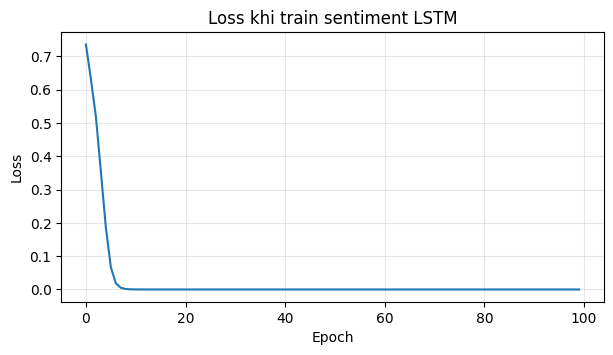

In [4]:

X_train, y_train = X_train.to(device), y_train.to(device)
loss_history = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train, lens_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}  loss = {loss.item():.4f}')

plt.figure(figsize=(7, 3.5))
plt.plot(loss_history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.title('Loss khi train sentiment LSTM'); plt.show()

In [5]:
# Test trên câu KHÔNG có trong tập train.
test_sentences = [
    'I like sun',          # mong là tích cực
    'I hate movies',       # mong là tiêu cực
    'I love music',        # mong là tích cực
    'I not love rain',     # khó — "not" + "love" + "rain"
]

def predict(sentence):
    tokens = [vocab[w] for w in sentence.split() if w in vocab]
    if not tokens:
        return None
    seq = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    length = torch.tensor([len(tokens)])
    model.eval()
    with torch.no_grad():
        logits = model(seq, length)
        proba = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    return proba

for s in test_sentences:
    p = predict(s)
    label = 'Tích cực' if p[1] > 0.5 else 'Tiêu cực'
    print(f'"{s:25s}"  →  {label}  (P_pos={p[1]:.2f})')

"I like sun               "  →  Tích cực  (P_pos=1.00)
"I hate movies            "  →  Tiêu cực  (P_pos=0.00)
"I love music             "  →  Tích cực  (P_pos=1.00)
"I not love rain          "  →  Tiêu cực  (P_pos=0.00)


## BÀI THỰC HÀNH : PHẦN 2

In [6]:
def make_long_dependency_data(n_samples=500, seq_len=30, n_noise_tokens=8):
    # Sinh dữ liệu mà nhãn phụ thuộc vào ký tự đầu tiên, các bước giữa là nhiễu.
    # Token 0 hoặc 1: signal. Token 2..n_noise_tokens+1: noise.
    X, y = [], []
    for _ in range(n_samples):
        signal = np.random.randint(0, 2)            # 0 hoặc 1
        noise = np.random.randint(2, 2 + n_noise_tokens, size=seq_len - 1)
        seq = np.concatenate([[signal], noise])
        X.append(seq); y.append(signal)
    return torch.tensor(np.array(X), dtype=torch.long), torch.tensor(y, dtype=torch.long)

Xs_train, ys_train = make_long_dependency_data(800)
Xs_test,  ys_test  = make_long_dependency_data(200)
print('train shape:', Xs_train.shape, ' test shape:', Xs_test.shape)
print('Ví dụ một chuỗi:', Xs_train[0].tolist(), '   nhãn:', ys_train[0].item())

train shape: torch.Size([800, 30])  test shape: torch.Size([200, 30])
Ví dụ một chuỗi: [0, 5, 6, 8, 4, 9, 6, 6, 8, 3, 4, 8, 4, 4, 9, 6, 5, 9, 9, 4, 7, 6, 3, 9, 5, 7, 7, 3, 9, 5]    nhãn: 0


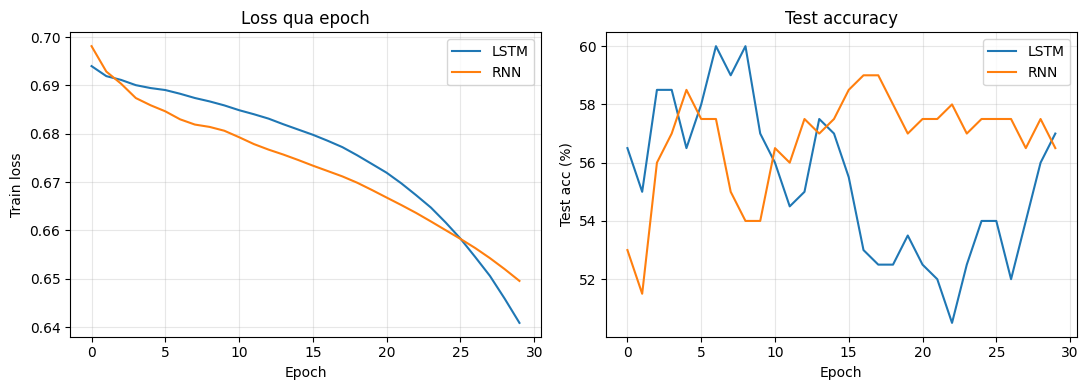

LSTM final test acc: 57.00%
RNN  final test acc: 56.50%

LSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).


In [7]:
class TokenModel(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=8, hidden_dim=16, cell='lstm'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        if cell == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_dim, 2)
        self.cell = cell

    def forward(self, x):
        e = self.embedding(x)
        if self.cell == 'lstm':
            _, (h_n, _) = self.rnn(e)
        else:
            _, h_n = self.rnn(e)
        return self.fc(h_n.squeeze(0))

def train_compare(cell, epochs=30, lr=0.01):
    torch.manual_seed(42)
    m = TokenModel(cell=cell).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    Xt, yt = Xs_train.to(device), ys_train.to(device)
    Xv, yv = Xs_test.to(device),  ys_test.to(device)
    losses, accs = [], []
    for ep in range(epochs):
        m.train()
        opt.zero_grad()
        loss = crit(m(Xt), yt)
        loss.backward()
        opt.step()
        m.eval()
        with torch.no_grad():
            acc = (m(Xv).argmax(1) == yv).float().mean().item()
        losses.append(loss.item()); accs.append(acc)
    return losses, accs

losses_lstm, accs_lstm = train_compare('lstm')
losses_rnn,  accs_rnn  = train_compare('rnn')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(losses_lstm, label='LSTM'); axes[0].plot(losses_rnn, label='RNN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss qua epoch')
axes[1].plot([a*100 for a in accs_lstm], label='LSTM')
axes[1].plot([a*100 for a in accs_rnn],  label='RNN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

print(f'LSTM final test acc: {accs_lstm[-1]*100:.2f}%')
print(f'RNN  final test acc: {accs_rnn[-1]*100:.2f}%')
print('\nLSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).')

## BÀI TẬP VỀ NHÀ

## BÀI 1

Test MSE - LSTM: 0.001436
Test MSE - RNN:  0.000935


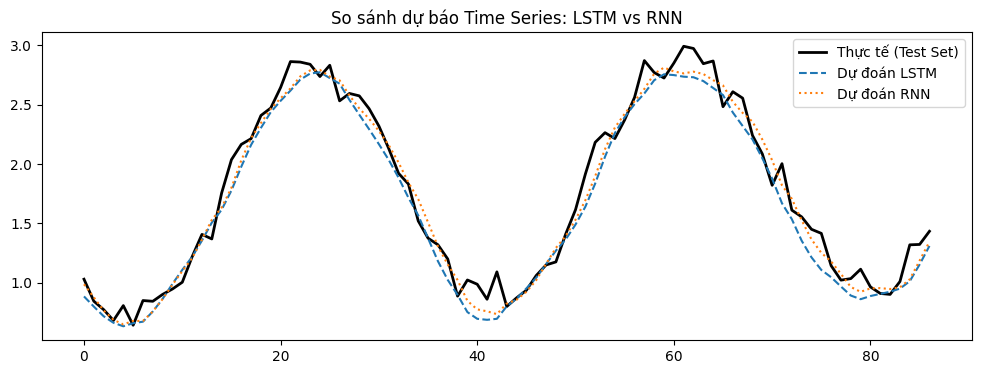

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Sinh dữ liệu (Sóng sin + Trend + Noise)
N = 600
t = np.linspace(0, 100, N)
data = np.sin(t) + 0.02 * t + 0.1 * np.random.randn(N)
data = data.reshape(-1, 1)

# Chuẩn hoá Min-Max
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# 2. Tạo cửa sổ trượt (seq_length = 20)
seq_length = 20
X, y = [], []
for i in range(len(data_scaled) - seq_length):
    X.append(data_scaled[i:i+seq_length])
    y.append(data_scaled[i+seq_length])

X = torch.FloatTensor(np.array(X))
y = torch.FloatTensor(np.array(y))

# Chia 70/15/15 train/val/test
n = len(X)
train_end, val_end = int(0.7 * n), int(0.85 * n)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=False)

# 3. Build LSTM và RNN Model
class TimeSeriesModel(nn.Module):
    def __init__(self, cell_type='lstm', input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.cell_type = cell_type
        if cell_type == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        if self.cell_type == 'lstm':
            out, (h_n, c_n) = self.rnn(x)
        else:
            out, h_n = self.rnn(x)
        return self.fc(h_n.squeeze(0))

def train_and_eval(cell_type):
    model = TimeSeriesModel(cell_type=cell_type).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Train 100 epochs
    for epoch in range(100):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()

    # Đánh giá trên tập Test
    model.eval()
    with torch.no_grad():
        preds = model(X_test.to(device)).cpu().numpy()
        truth = y_test.numpy()
        mse = np.mean((preds - truth)**2)
    return preds, truth, mse

# 4 & 5 & 6. Huấn luyện, đánh giá và so sánh
preds_lstm, truth, mse_lstm = train_and_eval('lstm')
preds_rnn, _, mse_rnn = train_and_eval('rnn')

print(f"Test MSE - LSTM: {mse_lstm:.6f}")
print(f"Test MSE - RNN:  {mse_rnn:.6f}")

# Vẽ đồ thị
preds_lstm_inv = scaler.inverse_transform(preds_lstm)
preds_rnn_inv = scaler.inverse_transform(preds_rnn)
truth_inv = scaler.inverse_transform(truth)

plt.figure(figsize=(12, 4))
plt.plot(truth_inv, label='Thực tế (Test Set)', color='black', linewidth=2)
plt.plot(preds_lstm_inv, label='Dự đoán LSTM', linestyle='--')
plt.plot(preds_rnn_inv, label='Dự đoán RNN', linestyle=':')
plt.legend(); plt.title('So sánh dự báo Time Series: LSTM vs RNN')
plt.show()

## BÀI 2

In [9]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import torch.optim as optim

# 1. Dữ liệu giả lập (Hãy thay bằng df['text'] và df['label'] từ VLSP dataset của bạn)
raw_data = [
    ("Sản phẩm rất tuyệt vời, tôi cực kỳ thích", 1),
    ("Chất lượng quá kém, không bao giờ mua lại", 0),
    ("Dịch vụ ổn, nhưng giao hàng hơi chậm", 0),
    ("Màu sắc đẹp, đóng gói cẩn thận, 10 điểm", 1),
    ("Rất thất vọng về cách làm việc của shop", 0),
    ("Hàng chính hãng, xài rất mượt", 1)
] * 170 # Nhân bản lên ~1000 câu để đủ train

# Build vocabulary đơn giản
vocab = {'<pad>': 0, '<unk>': 1}
for text, _ in raw_data:
    for word in text.lower().split():
        if word not in vocab:
            vocab[word] = len(vocab)

# Mã hoá
X_encoded, y_labels, lengths = [], [], []
for text, label in raw_data:
    tokens = [vocab.get(w, 1) for w in text.lower().split()]
    X_encoded.append(torch.tensor(tokens, dtype=torch.long))
    y_labels.append(label)
    lengths.append(len(tokens))

# 2. Pad sequence
X_padded = pad_sequence(X_encoded, batch_first=True, padding_value=0)
y_tensor = torch.tensor(y_labels, dtype=torch.long)
lengths_tensor = torch.tensor(lengths, dtype=torch.long)

# 3. Build Bidirectional LSTM Model
class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # LSTM 2 tầng, có Dropout và Bidirectional
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=0.5, bidirectional=True)

        # Đầu vào FC là 2 * hidden_dim do có 2 chiều (trái->phải, phải->trái)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        # Pack sequence để bỏ qua padding
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)

        # h_n shape: (num_layers * num_directions, batch, hidden_dim)
        # Lấy hidden state ở layer cuối cùng của cả 2 chiều
        # h_n[-2]: chiều xuôi, h_n[-1]: chiều ngược
        hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)

        out = self.dropout(hidden)
        return self.fc(out)

# Huấn luyện
model_sentiment = BiLSTMSentiment(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_sentiment.parameters(), lr=0.005)

print("Đang huấn luyện mô hình Bidirectional LSTM...")
for epoch in range(20):
    model_sentiment.train()
    optimizer.zero_grad()

    # Trong thực tế, bạn cần chia DataLoader, ở đây train trực tiếp toàn bộ batch để demo
    logits = model_sentiment(X_padded.to(device), lengths_tensor)
    loss = criterion(logits, y_tensor.to(device))
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        preds = logits.argmax(1)
        acc = (preds == y_tensor.to(device)).float().mean().item()
        print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Accuracy: {acc*100:.2f}%")

Đang huấn luyện mô hình Bidirectional LSTM...
Epoch 05 | Loss: 0.2295 | Accuracy: 100.00%
Epoch 10 | Loss: 0.0005 | Accuracy: 100.00%
Epoch 15 | Loss: 0.0000 | Accuracy: 100.00%
Epoch 20 | Loss: 0.0000 | Accuracy: 100.00%


## BÀI 3

In [10]:
import torch.nn.functional as F

# 1. Dữ liệu và Tiền xử lý
text = """Trăm năm trong cõi người ta,
Chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu,
Những điều trông thấy mà đau đớn lòng.
Lạ gì bỉ sắc tư phong,
Trời xanh quen thói má hồng đánh ghen.""" * 5 # Lặp lại để tăng lượng data

chars = tuple(set(text))
int2char = dict(enumerate(chars))
char2int = {ch: ii for ii, ch in int2char.items()}
encoded = np.array([char2int[ch] for ch in text])

# 2. Tạo input/target (seq_length = 50)
seq_length = 50
X_chars, y_chars = [], []
for i in range(0, len(encoded) - seq_length):
    X_chars.append(encoded[i:i+seq_length])
    y_chars.append(encoded[i+1:i+seq_length+1]) # Dịch 1 ký tự sang phải

X_chars = torch.tensor(X_chars, dtype=torch.long)
y_chars = torch.tensor(y_chars, dtype=torch.long)

# 3. Model Sinh Văn Bản
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=128, num_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out.reshape(-1, out.size(2))) # Flatten trước khi vào FC
        return out, hidden

char_model = CharLSTM(len(chars)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(char_model.parameters(), lr=0.01)

# Train nhanh
char_model.train()
hidden = None
for epoch in range(100):
    optimizer.zero_grad()
    X_b, y_b = X_chars.to(device), y_chars.to(device)

    out, _ = char_model(X_b, None)
    loss = criterion(out, y_b.view(-1))
    loss.backward()
    optimizer.step()

# 4. Hàm sinh văn bản với Temperature Sampling
def generate_text(model, seed, size=100, temperature=1.0):
    model.eval()
    chars_gen = [ch for ch in seed]
    h = None

    with torch.no_grad():
        for _ in range(size):
            # Lấy toàn bộ lịch sử đã sinh đưa vào model
            seq = torch.tensor([[char2int[ch] for ch in chars_gen]]).to(device)
            out, h = model(seq, None)

            # Lấy output của ký tự cuối cùng
            logits = out[-1]

            # Áp dụng temperature
            probs = F.softmax(logits / temperature, dim=0).cpu().numpy()

            # Tránh chia cho 0 hoặc lỗi phân phối do độ chính xác float
            probs = probs / np.sum(probs)

            # Lấy mẫu ngẫu nhiên dựa trên xác suất
            top_char_idx = np.random.choice(len(chars), p=probs)
            chars_gen.append(int2char[top_char_idx])

    return ''.join(chars_gen)

print("--- Kết quả sinh văn bản (Temperature = 0.8) ---")
print(generate_text(char_model, seed="Trăm năm", size=150, temperature=0.8))

/tmp/ipykernel_5671/596885605.py:23: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X_chars = torch.tensor(X_chars, dtype=torch.long)


--- Kết quả sinh văn bản (Temperature = 0.8) ---
Trăm năm trong cõi người ta,
Chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu,
Những điều trông thấy mà đau đớn lòng.
Lạ gì bỉ sắc tư phong,
Trời 
